# Warehouse Grid Generation (Floors 1-2 and 3-4)

**Description:** This notebook builds and visualizes warehouse grids only (no storage/picking tasks).

It models:
- Walls, aisles, pillars, racks
- Bureau (`15 x 8`), Montre de charge (`15 x 8`), Assenseur (`5 x 3`)
- Rack segments where each `stockage en rack` contains exactly `3` cells
- Initial pallet occupancy in column 1 for selected rack segments

## 1) Detailed Cell Structure Applied

**Description:** Uses the provided detailed structure for sections A, B, C, D, E and infrastructure.

- Rack blocks are modeled as `3 x 8` or `3 x 4` exactly as specified.
- Two goods lifts are modeled as `4 x 8` each.
- Elevator is modeled as `5 x 3`.
- Perimeter walls are modeled as thick (2 cells), with interior wall borders (1 cell) around infrastructure.
- Occupied pallets are placed in: `A1`, `B7`, `C1`, `D1` (two), `E1`, `E2`, `E10` (two).
- Empty areas remain walkable aisles.

Note: The same detailed structure is currently rendered for floor groups `1-2` and `3-4` using this image-based configuration.

In [7]:
# Description: Exact warehouse floor-grid model matching provided floor-plan specifications.

from dataclasses import dataclass
from enum import Enum
from pathlib import Path
from typing import Dict, List, Tuple

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch, Rectangle

Coordinate = Tuple[int, int]


class CellType(str, Enum):
    AISLE = "aisle"
    RACK = "rack"
    WALL = "wall"
    ELEVATOR = "elevator"
    GOODS_LIFT = "goods_lift"
    GROUND_STORAGE = "ground_storage"
    OCCUPIED = "occupied"


@dataclass
class GridCell:
    x: int
    y: int
    cell_type: CellType
    rack_id: str | None = None


@dataclass
class RackSpec:
    rack_id: str
    width: int
    height: int
    occupied: int


@dataclass
class FloorMeta:
    name: str
    walkable_approx: int
    walls_approx: int


def make_empty_grid(width: int, height: int) -> List[List[GridCell]]:
    return [[GridCell(x=x, y=y, cell_type=CellType.AISLE) for x in range(width)] for y in range(height)]


def in_bounds(grid: List[List[GridCell]], x: int, y: int) -> bool:
    return 0 <= y < len(grid) and 0 <= x < len(grid[0])


def fill_rect(
    grid: List[List[GridCell]],
    x1: int,
    y1: int,
    x2: int,
    y2: int,
    cell_type: CellType,
    rack_id: str | None = None,
) -> None:
    for y in range(y1, y2 + 1):
        for x in range(x1, x2 + 1):
            if in_bounds(grid, x, y):
                grid[y][x].cell_type = cell_type
                grid[y][x].rack_id = rack_id


def make_specs_floor_1_2() -> Dict[str, RackSpec]:
    specs: Dict[str, RackSpec] = {}

    # SECTION A
    for i in [1, 2, 3, 4]:
        specs[f"A{i}"] = RackSpec(f"A{i}", 3, 8, 1 if i == 1 else 0)
    for i in [5, 6, 7, 8]:
        specs[f"A{i}"] = RackSpec(f"A{i}", 3, 4, 0)

    # SECTION B
    for i in [1, 2, 3, 4, 5]:
        specs[f"B{i}"] = RackSpec(f"B{i}", 3, 8, 0)
    specs["B7"] = RackSpec("B7", 3, 8, 1)
    specs["B8"] = RackSpec("B8", 3, 4, 0)

    # SECTION C
    for i in range(1, 10):
        specs[f"C{i}"] = RackSpec(f"C{i}", 3, 8, 1 if i == 1 else 0)

    # SECTION D
    for i in range(1, 9):
        specs[f"D{i}"] = RackSpec(f"D{i}", 3, 8, 2 if i == 1 else 0)

    # SECTION E
    for i in range(1, 19):
        occ = 1 if i in [1, 2] else 2 if i == 10 else 0
        specs[f"E{i}"] = RackSpec(f"E{i}", 3, 8, occ)

    return specs


def make_specs_floor_3_4() -> Dict[str, RackSpec]:
    specs: Dict[str, RackSpec] = {}

    # SECTION A
    for i in [1, 2, 3, 4]:
        specs[f"A{i}"] = RackSpec(f"A{i}", 3, 8, 0)
    for i in [5, 6]:
        specs[f"A{i}"] = RackSpec(f"A{i}", 3, 4, 0)

    # SECTION B
    for i in [1, 2, 3, 4]:
        specs[f"B{i}"] = RackSpec(f"B{i}", 3, 8, 0)
    for i in [5, 6]:
        specs[f"B{i}"] = RackSpec(f"B{i}", 3, 4, 0)

    # SECTION C
    for i in range(1, 13):
        specs[f"C{i}"] = RackSpec(f"C{i}", 3, 8, 1 if i == 11 else 0)

    # SECTION D
    for i in range(1, 15):
        specs[f"D{i}"] = RackSpec(f"D{i}", 3, 8, 1 if i == 13 else 0)

    # SECTION E
    for i in range(1, 18):
        specs[f"E{i}"] = RackSpec(f"E{i}", 3, 8, 1 if i == 16 else 0)

    return specs


def occupied_positions(rack_id: str, occupied_count: int, rack_height: int) -> List[Tuple[int, int]]:
    if occupied_count == 0:
        return []

    if rack_id == "A1":
        ys = [rack_height - 1]
    elif rack_id == "B7":
        ys = [0]
    elif rack_id in ["D1", "E10"] and occupied_count == 2:
        ys = [2, rack_height - 2]
    else:
        ys = [rack_height // 2]

    ys = ys[:occupied_count]
    while len(ys) < occupied_count:
        ys.append(min(rack_height - 1, len(ys) + 1))

    return [(1, y) for y in ys]


def place_rack(
    grid: List[List[GridCell]],
    spec: RackSpec,
    x: int,
    y: int,
    registry: Dict[str, Dict],
) -> None:
    x1, y1 = x, y
    x2, y2 = x + spec.width - 1, y + spec.height - 1
    fill_rect(grid, x1, y1, x2, y2, CellType.RACK, rack_id=spec.rack_id)

    registry[spec.rack_id] = {
        "section": spec.rack_id[0],
        "bounds": (x1, y1, x2, y2),
        "width": spec.width,
        "height": spec.height,
        "total_cells": spec.width * spec.height,
        "occupied_cells": 0,
        "empty_cells": spec.width * spec.height,
    }

    for rel_x, rel_y in occupied_positions(spec.rack_id, spec.occupied, spec.height):
        px, py = x1 + rel_x, y1 + rel_y
        if in_bounds(grid, px, py):
            grid[py][px].cell_type = CellType.OCCUPIED
            grid[py][px].rack_id = spec.rack_id
            registry[spec.rack_id]["occupied_cells"] += 1
            registry[spec.rack_id]["empty_cells"] -= 1


def add_common_infrastructure(grid: List[List[GridCell]], registry: Dict[str, Dict], height: int) -> None:
    width = len(grid[0])

    # Perimeter walls (2 cells thick)
    fill_rect(grid, 0, 0, width - 1, 1, CellType.WALL)
    fill_rect(grid, 0, height - 2, width - 1, height - 1, CellType.WALL)
    fill_rect(grid, 0, 0, 1, height - 1, CellType.WALL)
    fill_rect(grid, width - 2, 0, width - 1, height - 1, CellType.WALL)

    # Elevator (5x3) + border walls
    elev_x, elev_y = 6, 10
    fill_rect(grid, elev_x, elev_y, elev_x + 4, elev_y + 2, CellType.ELEVATOR)
    fill_rect(grid, elev_x - 1, elev_y - 1, elev_x + 5, elev_y - 1, CellType.WALL)
    fill_rect(grid, elev_x - 1, elev_y + 3, elev_x + 5, elev_y + 3, CellType.WALL)
    fill_rect(grid, elev_x - 1, elev_y - 1, elev_x - 1, elev_y + 3, CellType.WALL)
    fill_rect(grid, elev_x + 5, elev_y - 1, elev_x + 5, elev_y + 3, CellType.WALL)
    registry["ELEVATOR"] = {"bounds": (elev_x, elev_y, elev_x + 4, elev_y + 2), "total_cells": 15}

    # Goods lifts (4x8 each) + border walls
    lift1_x, lift1_y = 60, 8
    fill_rect(grid, lift1_x, lift1_y, lift1_x + 3, lift1_y + 7, CellType.GOODS_LIFT)
    fill_rect(grid, lift1_x - 1, lift1_y - 1, lift1_x + 4, lift1_y - 1, CellType.WALL)
    fill_rect(grid, lift1_x - 1, lift1_y + 8, lift1_x + 4, lift1_y + 8, CellType.WALL)
    fill_rect(grid, lift1_x - 1, lift1_y - 1, lift1_x - 1, lift1_y + 8, CellType.WALL)
    fill_rect(grid, lift1_x + 4, lift1_y - 1, lift1_x + 4, lift1_y + 8, CellType.WALL)
    registry["GOODS_LIFT_1"] = {"bounds": (lift1_x, lift1_y, lift1_x + 3, lift1_y + 7), "total_cells": 32}

    lift2_x, lift2_y = 66, 8
    fill_rect(grid, lift2_x, lift2_y, lift2_x + 3, lift2_y + 7, CellType.GOODS_LIFT)
    fill_rect(grid, lift2_x - 1, lift2_y - 1, lift2_x + 4, lift2_y - 1, CellType.WALL)
    fill_rect(grid, lift2_x - 1, lift2_y + 8, lift2_x + 4, lift2_y + 8, CellType.WALL)
    fill_rect(grid, lift2_x - 1, lift2_y - 1, lift2_x - 1, lift2_y + 8, CellType.WALL)
    fill_rect(grid, lift2_x + 4, lift2_y - 1, lift2_x + 4, lift2_y + 8, CellType.WALL)
    registry["GOODS_LIFT_2"] = {"bounds": (lift2_x, lift2_y, lift2_x + 3, lift2_y + 7), "total_cells": 32}


def place_floor_1_2_racks(grid: List[List[GridCell]], specs: Dict[str, RackSpec], registry: Dict[str, Dict]) -> None:
    gap = 2

    # Top lanes (B and A)
    y_top = 4
    x_b = 20
    for i, rack_id in enumerate(["B5", "B4", "B3", "B2", "B1"]):
        place_rack(grid, specs[rack_id], x_b + i * (3 + gap), y_top, registry)

    place_rack(grid, specs["B7"], 8, y_top + 5, registry)
    place_rack(grid, specs["B8"], 8, y_top, registry)

    x_a_right = 82
    place_rack(grid, specs["A5"], x_a_right, y_top, registry)
    place_rack(grid, specs["A6"], x_a_right - 5, y_top, registry)
    place_rack(grid, specs["A7"], x_a_right - 10, y_top, registry)
    place_rack(grid, specs["A8"], x_a_right - 15, y_top, registry)

    y_a_tall = 12
    for i, rack_id in enumerate(["A4", "A3", "A2", "A1"]):
        place_rack(grid, specs[rack_id], x_a_right - i * (3 + gap), y_a_tall, registry)

    # Middle lane (D then C)
    y_mid = 24
    x_d = 8
    for i, rack_id in enumerate(["D8", "D7", "D6", "D5", "D4", "D3", "D2", "D1"]):
        place_rack(grid, specs[rack_id], x_d + i * (3 + gap), y_mid, registry)

    x_c = 50
    for i, rack_id in enumerate(["C9", "C8", "C7", "C6", "C5", "C4", "C3", "C2", "C1"]):
        place_rack(grid, specs[rack_id], x_c + i * (3 + gap), y_mid, registry)

    # Bottom lane (E18..E1)
    y_bottom = 42
    x_e = 4
    for i in range(18, 0, -1):
        rack_id = f"E{i}"
        place_rack(grid, specs[rack_id], x_e, y_bottom, registry)
        x_e += 3 + 1


def place_floor_3_4_racks(grid: List[List[GridCell]], specs: Dict[str, RackSpec], registry: Dict[str, Dict]) -> None:
    gap = 2

    # Top lanes (B and A)
    y_top = 4
    x_b = 20
    for i, rack_id in enumerate(["B4", "B3", "B2", "B1"]):
        place_rack(grid, specs[rack_id], x_b + i * (3 + gap), y_top, registry)

    place_rack(grid, specs["B5"], 8, y_top, registry)
    place_rack(grid, specs["B6"], 8, y_top + 5, registry)

    x_a_right = 82
    place_rack(grid, specs["A5"], x_a_right, y_top, registry)
    place_rack(grid, specs["A6"], x_a_right - 5, y_top, registry)

    y_a_tall = 12
    for i, rack_id in enumerate(["A4", "A3", "A2", "A1"]):
        place_rack(grid, specs[rack_id], x_a_right - i * (3 + gap), y_a_tall, registry)

    # Middle lane (D and C)
    y_mid_1 = 24
    x_d = 4
    for i in range(14, 7, -1):
        rack_id = f"D{i}"
        place_rack(grid, specs[rack_id], x_d, y_mid_1, registry)
        x_d += 3 + 1

    x_c = 48
    for i in range(12, 6, -1):
        rack_id = f"C{i}"
        place_rack(grid, specs[rack_id], x_c, y_mid_1, registry)
        x_c += 3 + 1

    y_mid_2 = 34
    x_d2 = 4
    for i in range(7, 0, -1):
        rack_id = f"D{i}"
        place_rack(grid, specs[rack_id], x_d2, y_mid_2, registry)
        x_d2 += 3 + 1

    x_c2 = 56
    for i in range(6, 0, -1):
        rack_id = f"C{i}"
        place_rack(grid, specs[rack_id], x_c2, y_mid_2, registry)
        x_c2 += 3 + 1

    # Bottom lane (E17..E1)
    y_bottom = 46
    x_e = 4
    for i in range(17, 0, -1):
        rack_id = f"E{i}"
        place_rack(grid, specs[rack_id], x_e, y_bottom, registry)
        x_e += 3 + 1


def build_floor_1_2_grid() -> Tuple[List[List[GridCell]], Dict[str, Dict], Dict[str, RackSpec], FloorMeta]:
    width, height = 90, 58
    grid = make_empty_grid(width, height)
    registry: Dict[str, Dict] = {}
    specs = make_specs_floor_1_2()

    add_common_infrastructure(grid, registry, height)
    place_floor_1_2_racks(grid, specs, registry)

    meta = FloorMeta(name="FLOORS 1 & 2", walkable_approx=400, walls_approx=240)
    return grid, registry, specs, meta


def build_floor_3_4_grid() -> Tuple[List[List[GridCell]], Dict[str, Dict], Dict[str, RackSpec], FloorMeta]:
    width, height = 90, 58
    grid = make_empty_grid(width, height)
    registry: Dict[str, Dict] = {}
    specs = make_specs_floor_3_4()

    add_common_infrastructure(grid, registry, height)
    place_floor_3_4_racks(grid, specs, registry)

    meta = FloorMeta(name="FLOORS 3 & 4", walkable_approx=425, walls_approx=245)
    return grid, registry, specs, meta


def calculate_statistics(registry: Dict[str, Dict], specs: Dict[str, RackSpec]) -> Dict:
    stats = {
        "total_rack_cells": 0,
        "total_occupied_cells": 0,
        "total_empty_rack_cells": 0,
        "operational_cells": 0,
        "sections": {},
        "racks": {},
    }

    for rack_id in sorted(specs.keys(), key=lambda r: (r[0], int(r[1:]))):
        info = registry[rack_id]
        section = rack_id[0]

        stats["total_rack_cells"] += info["total_cells"]
        stats["total_occupied_cells"] += info["occupied_cells"]
        stats["total_empty_rack_cells"] += info["empty_cells"]
        stats["racks"][rack_id] = info

        if section not in stats["sections"]:
            stats["sections"][section] = {
                "total_cells": 0,
                "occupied_cells": 0,
                "empty_cells": 0,
                "racks": [],
            }

        stats["sections"][section]["total_cells"] += info["total_cells"]
        stats["sections"][section]["occupied_cells"] += info["occupied_cells"]
        stats["sections"][section]["empty_cells"] += info["empty_cells"]
        stats["sections"][section]["racks"].append(rack_id)

    stats["operational_cells"] = (
        registry["ELEVATOR"]["total_cells"]
        + registry["GOODS_LIFT_1"]["total_cells"]
        + registry["GOODS_LIFT_2"]["total_cells"]
    )

    return stats


def print_detailed_report(floor_title: str, stats: Dict, registry: Dict[str, Dict], specs: Dict[str, RackSpec], meta: FloorMeta) -> None:
    print(f"\n🏢 PLAN DE STOCKAGE {floor_title}")
    print("RACK SECTIONS:")

    for section in ["A", "B", "C", "D", "E"]:
        racks = sorted([r for r in specs if r.startswith(section)], key=lambda r: int(r[1:]))
        print(f"SECTION {section} ({len(racks)} positions):\n")

        for rack_id in racks:
            info = registry[rack_id]
            print(
                f"{rack_id}: {info['width']} cells wide × {info['height']} cells high = {info['total_cells']} cells"
                f" | Contains: {info['occupied_cells']} pallet{'s' if info['occupied_cells'] != 1 else ''}"
                f" | Empty: {info['empty_cells']} cells"
            )

        sec = stats["sections"][section]
        print(
            f"TOTAL SECTION {section}: {sec['total_cells']} cells | {sec['occupied_cells']} pallets | {sec['empty_cells']} empty"
        )

    print("SPECIAL AREAS:")
    print("Ascenseur (Elevator):")
    print("Size: 5 cells wide × 3 cells high = 15 cells")
    print("Type: Operational/Empty (elevator shaft)")
    print("Occupied: 0 cells | Empty: 15 cells\n")

    print("Montée de charge 1 (Goods Lift 1):")
    print("Size: 4 cells wide × 8 cells high = 32 cells")
    print("Type: Operational/Empty (lift shaft)")
    print("Occupied: 0 cells | Empty: 32 cells\n")

    print("Montée de charge 2 (Goods Lift 2):")
    print("Size: 4 cells wide × 8 cells high = 32 cells")
    print("Type: Operational/Empty (lift shaft)")
    print("Occupied: 0 cells | Empty: 32 cells\n")

    print("CIRCULATION & WALLS:")
    print(f"Walkable Paths (White spaces): ~{meta.walkable_approx} cells")
    print(f"Walls (Dark borders): ~{meta.walls_approx} cells")


def print_global_summary(stats_12: Dict, meta_12: FloorMeta, stats_34: Dict, meta_34: FloorMeta) -> None:
    print("\n📊 GLOBAL SUMMARY - ALL FLOORS")

    total_12 = (
        stats_12["total_rack_cells"]
        + stats_12["operational_cells"]
        + meta_12.walkable_approx
        + meta_12.walls_approx
    )
    total_34 = (
        stats_34["total_rack_cells"]
        + stats_34["operational_cells"]
        + meta_34.walkable_approx
        + meta_34.walls_approx
    )

    print("FLOORS 1 & 2:")
    print(f"Total Rack Storage Cells: {stats_12['total_rack_cells']:,} cells")
    print(f"Occupied Pallet Cells: {stats_12['total_occupied_cells']:,} cells")
    print(f"Empty Rack Cells: {stats_12['total_empty_rack_cells']:,} cells")
    print(f"Operational Cells (Lifts + Elevator): {stats_12['operational_cells']:,} cells")
    print(f"Walkable Path Cells: ~{meta_12.walkable_approx:,} cells")
    print(f"Wall Cells: ~{meta_12.walls_approx:,} cells")
    print(f"GRAND TOTAL: ~{total_12:,} cells\n")

    print("FLOORS 3 & 4:")
    print(f"Total Rack Storage Cells: {stats_34['total_rack_cells']:,} cells")
    print(f"Occupied Pallet Cells: {stats_34['total_occupied_cells']:,} cells")
    print(f"Empty Rack Cells: {stats_34['total_empty_rack_cells']:,} cells")
    print(f"Operational Cells (Lifts + Elevator): {stats_34['operational_cells']:,} cells")
    print(f"Walkable Path Cells: ~{meta_34.walkable_approx:,} cells")
    print(f"Wall Cells: ~{meta_34.walls_approx:,} cells")
    print(f"GRAND TOTAL: ~{total_34:,} cells\n")

    print("ALL FLOORS COMBINED (1-4):")
    print(f"Total Rack Storage Cells: {stats_12['total_rack_cells'] + stats_34['total_rack_cells']:,} cells")
    print(f"Occupied Pallet Cells: {stats_12['total_occupied_cells'] + stats_34['total_occupied_cells']:,} cells")
    print(f"Empty Rack Cells: {stats_12['total_empty_rack_cells'] + stats_34['total_empty_rack_cells']:,} cells")
    print(f"Operational Cells: {stats_12['operational_cells'] + stats_34['operational_cells']:,} cells")
    print(f"Walkable Path Cells: ~{meta_12.walkable_approx + meta_34.walkable_approx:,} cells")
    print(f"Wall Cells: ~{meta_12.walls_approx + meta_34.walls_approx:,} cells")
    print(f"GRAND TOTAL: ~{total_12 + total_34:,} cells")


def plot_grid(ax, grid: List[List[GridCell]], title: str, registry: Dict[str, Dict]) -> None:
    cell_type_to_index = {
        CellType.AISLE: 0,
        CellType.RACK: 1,
        CellType.WALL: 2,
        CellType.ELEVATOR: 3,
        CellType.GOODS_LIFT: 4,
        CellType.GROUND_STORAGE: 5,
        CellType.OCCUPIED: 6,
    }
    colors = [
        "#FFFFFF",  # aisle
        "#E8DDB5",  # rack
        "#8B7355",  # wall
        "#B0C4DE",  # elevator
        "#87CEEB",  # goods lift
        "#D4C99A",  # ground storage
        "#FFFFFF",  # occupied marker fill
    ]

    h = len(grid)
    w = len(grid[0])
    idx = np.array([[cell_type_to_index[cell.cell_type] for cell in row] for row in grid])
    ax.imshow(idx, cmap=ListedColormap(colors), origin="upper", interpolation="nearest", aspect="equal")

    ax.set_xticks([x - 0.5 for x in range(w)], minor=True)
    ax.set_yticks([y - 0.5 for y in range(h)], minor=True)
    ax.grid(which="minor", color="#8B7355", linestyle="-", linewidth=0.25, alpha=0.5)
    ax.tick_params(which="both", bottom=False, left=False, labelbottom=False, labelleft=False)

    # Labels
    done = set()
    for rack_id, info in registry.items():
        if rack_id in ["ELEVATOR", "GOODS_LIFT_1", "GOODS_LIFT_2"]:
            continue
        if rack_id in done:
            continue
        x1, y1, x2, y2 = info["bounds"]
        ax.text((x1 + x2) / 2, y1 - 0.8, rack_id, fontsize=6, ha="center", va="bottom", weight="bold")
        done.add(rack_id)

    for y in range(h):
        for x in range(w):
            if grid[y][x].cell_type == CellType.OCCUPIED:
                ax.add_patch(Rectangle((x - 0.4, y - 0.4), 0.8, 0.8, edgecolor="#8B7355", facecolor="white", linewidth=1.0, zorder=5))

    ax.set_title(title, fontsize=16, weight="bold", pad=12)


# Public function for execution cell

def build_all_and_report(save_image: bool = True) -> None:
    grid_12, reg_12, specs_12, meta_12 = build_floor_1_2_grid()
    grid_34, reg_34, specs_34, meta_34 = build_floor_3_4_grid()

    stats_12 = calculate_statistics(reg_12, specs_12)
    stats_34 = calculate_statistics(reg_34, specs_34)

    print_detailed_report("1ER ET 2ÈME (FLOORS 1 & 2)", stats_12, reg_12, specs_12, meta_12)
    print_detailed_report("3ÈME ET 4ÈME (FLOORS 3 & 4)", stats_34, reg_34, specs_34, meta_34)
    print_global_summary(stats_12, meta_12, stats_34, meta_34)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(24, 12))
    plot_grid(ax1, grid_12, "Plan de stockage 1er et 2ème", reg_12)
    plot_grid(ax2, grid_34, "Plan de stockage 3ème et 4ème", reg_34)
    plt.tight_layout()

    if save_image:
        output_dir = Path("ai/Amina/outputs")
        output_dir.mkdir(parents=True, exist_ok=True)
        output_file = output_dir / "warehouse_all_floors_exact.png"
        plt.savefig(output_file, dpi=300, bbox_inches="tight")
        print(f"\nVisualization saved to: {output_file}")

    plt.show()

In [13]:
# Description: Rack logic, slot indexing, location codec, and storage policy engine.

import re
from dataclasses import dataclass
from typing import Optional


def place_racks_from_layout(
    grid: List[List[GridCell]],
    specs: Dict[str, RackSpec],
    registry: Dict[str, Dict],
    layout: Dict[str, Tuple[int, int]],
) -> None:
    for rack_id, (x, y) in layout.items():
        place_rack(grid, specs[rack_id], x, y, registry)


def add_common_infrastructure(grid: List[List[GridCell]], registry: Dict[str, Dict], height: int) -> None:
    width = len(grid[0])

    # Perimeter walls (2 cells thick)
    fill_rect(grid, 0, 0, width - 1, 1, CellType.WALL)
    fill_rect(grid, 0, height - 2, width - 1, height - 1, CellType.WALL)
    fill_rect(grid, 0, 0, 1, height - 1, CellType.WALL)
    fill_rect(grid, width - 2, 0, width - 1, height - 1, CellType.WALL)

    # Elevator (left-top)
    elev_x, elev_y = 5, 10
    fill_rect(grid, elev_x, elev_y, elev_x + 4, elev_y + 2, CellType.ELEVATOR)
    fill_rect(grid, elev_x - 1, elev_y - 1, elev_x + 5, elev_y - 1, CellType.WALL)
    fill_rect(grid, elev_x - 1, elev_y + 3, elev_x + 5, elev_y + 3, CellType.WALL)
    fill_rect(grid, elev_x - 1, elev_y - 1, elev_x - 1, elev_y + 3, CellType.WALL)
    fill_rect(grid, elev_x + 5, elev_y - 1, elev_x + 5, elev_y + 3, CellType.WALL)
    registry["ELEVATOR"] = {"bounds": (elev_x, elev_y, elev_x + 4, elev_y + 2), "total_cells": 15}

    # Goods lifts (center-right top)
    lift1_x, lift1_y = 63, 8
    fill_rect(grid, lift1_x, lift1_y, lift1_x + 3, lift1_y + 7, CellType.GOODS_LIFT)
    fill_rect(grid, lift1_x - 1, lift1_y - 1, lift1_x + 4, lift1_y - 1, CellType.WALL)
    fill_rect(grid, lift1_x - 1, lift1_y + 8, lift1_x + 4, lift1_y + 8, CellType.WALL)
    fill_rect(grid, lift1_x - 1, lift1_y - 1, lift1_x - 1, lift1_y + 8, CellType.WALL)
    fill_rect(grid, lift1_x + 4, lift1_y - 1, lift1_x + 4, lift1_y + 8, CellType.WALL)
    registry["GOODS_LIFT_1"] = {"bounds": (lift1_x, lift1_y, lift1_x + 3, lift1_y + 7), "total_cells": 32}

    lift2_x, lift2_y = 68, 8
    fill_rect(grid, lift2_x, lift2_y, lift2_x + 3, lift2_y + 7, CellType.GOODS_LIFT)
    fill_rect(grid, lift2_x - 1, lift2_y - 1, lift2_x + 4, lift2_y - 1, CellType.WALL)
    fill_rect(grid, lift2_x - 1, lift2_y + 8, lift2_x + 4, lift2_y + 8, CellType.WALL)
    fill_rect(grid, lift2_x - 1, lift2_y - 1, lift2_x - 1, lift2_y + 8, CellType.WALL)
    fill_rect(grid, lift2_x + 4, lift2_y - 1, lift2_x + 4, lift2_y + 8, CellType.WALL)
    registry["GOODS_LIFT_2"] = {"bounds": (lift2_x, lift2_y, lift2_x + 3, lift2_y + 7), "total_cells": 32}


def place_floor_1_2_racks(grid: List[List[GridCell]], specs: Dict[str, RackSpec], registry: Dict[str, Dict]) -> None:
    layout = {
        # B section
        "B8": (7, 3),
        "B7": (7, 8),
        "B5": (18, 3),
        "B4": (23, 3),
        "B3": (28, 3),
        "B2": (33, 3),
        "B1": (38, 3),

        # A section
        "A8": (43, 3),
        "A7": (50, 3),
        "A6": (55, 3),
        "A5": (60, 3),
        "A4": (75, 12),
        "A3": (80, 12),
        "A2": (85, 12),
        "A1": (90, 12),

        # D section
        "D8": (7, 24),
        "D7": (12, 24),
        "D6": (17, 24),
        "D5": (22, 24),
        "D4": (27, 24),
        "D3": (32, 24),
        "D2": (37, 24),
        "D1": (42, 24),

        # C section
        "C9": (49, 24),
        "C8": (54, 24),
        "C7": (59, 24),
        "C6": (64, 24),
        "C5": (69, 24),
        "C4": (74, 24),
        "C3": (79, 24),
        "C2": (84, 24),
        "C1": (89, 24),
    }

    place_racks_from_layout(grid, specs, registry, layout)

    # E section (E18 -> E1)
    x_e, y_e, step = 3, 42, 4
    for i in range(18, 0, -1):
        rack_id = f"E{i}"
        place_rack(grid, specs[rack_id], x_e, y_e, registry)
        x_e += step


def place_floor_3_4_racks(grid: List[List[GridCell]], specs: Dict[str, RackSpec], registry: Dict[str, Dict]) -> None:
    layout = {
        # B section
        "B6": (7, 8),
        "B5": (7, 3),
        "B4": (20, 3),
        "B3": (25, 3),
        "B2": (30, 3),
        "B1": (35, 3),

        # A section
        "A6": (82, 3),
        "A5": (87, 3),
        "A4": (87, 12),
        "A3": (82, 12),
        "A2": (77, 12),
        "A1": (72, 12),

        # Upper D section (D14..D8)
        "D14": (6, 24),
        "D13": (10, 24),
        "D12": (14, 24),
        "D11": (18, 24),
        "D10": (22, 24),
        "D9": (26, 24),
        "D8": (30, 24),

        # Upper C section (C12..C7)
        "C12": (54, 24),
        "C11": (58, 24),
        "C10": (62, 24),
        "C9": (66, 24),
        "C8": (70, 24),
        "C7": (74, 24),

        # Lower D section (D7..D1)
        "D7": (6, 34),
        "D6": (10, 34),
        "D5": (14, 34),
        "D4": (18, 34),
        "D3": (22, 34),
        "D2": (26, 34),
        "D1": (30, 34),

        # Lower C section (C6..C1)
        "C6": (62, 34),
        "C5": (66, 34),
        "C4": (70, 34),
        "C3": (74, 34),
        "C2": (78, 34),
        "C1": (82, 34),
    }

    place_racks_from_layout(grid, specs, registry, layout)

    # E section (E17 -> E1)
    x_e, y_e, step = 6, 46, 4
    for i in range(17, 0, -1):
        rack_id = f"E{i}"
        place_rack(grid, specs[rack_id], x_e, y_e, registry)
        x_e += step


def build_floor_1_2_grid() -> Tuple[List[List[GridCell]], Dict[str, Dict], Dict[str, RackSpec], FloorMeta]:
    width, height = 96, 58
    grid = make_empty_grid(width, height)
    registry: Dict[str, Dict] = {}
    specs = make_specs_floor_1_2()

    add_common_infrastructure(grid, registry, height)
    place_floor_1_2_racks(grid, specs, registry)

    meta = FloorMeta(name="FLOORS 1 & 2", walkable_approx=400, walls_approx=240)
    return grid, registry, specs, meta


def build_floor_3_4_grid() -> Tuple[List[List[GridCell]], Dict[str, Dict], Dict[str, RackSpec], FloorMeta]:
    width, height = 96, 58
    grid = make_empty_grid(width, height)
    registry: Dict[str, Dict] = {}
    specs = make_specs_floor_3_4()

    add_common_infrastructure(grid, registry, height)
    place_floor_3_4_racks(grid, specs, registry)

    meta = FloorMeta(name="FLOORS 3 & 4", walkable_approx=425, walls_approx=245)
    return grid, registry, specs, meta


def print_detailed_report(floor_title: str, stats: Dict, registry: Dict[str, Dict], specs: Dict[str, RackSpec], meta: FloorMeta) -> None:
    print(f"\n🏢 PLAN DE STOCKAGE {floor_title}")
    print("RACK SECTIONS:")

    for section in ["A", "B", "C", "D", "E"]:
        racks = sorted([r for r in specs if r.startswith(section)], key=lambda r: int(r[1:]))
        print(f"SECTION {section} ({len(racks)} positions):\n")

        for rack_id in racks:
            info = registry[rack_id]
            pallet_word = "pallet cell" if info["occupied_cells"] == 1 else "pallet cells"
            print(
                f"{rack_id}: {info['width']} cells wide × {info['height']} cells high = {info['total_cells']} cells"
                f" | Contains: {info['occupied_cells']} {pallet_word}"
                f" | Empty: {info['empty_cells']} cells"
            )

        sec = stats["sections"][section]
        pallet_word = "pallet" if sec["occupied_cells"] == 1 else "pallets"
        print(
            f"TOTAL SECTION {section}: {sec['total_cells']} cells | {sec['occupied_cells']} {pallet_word} | {sec['empty_cells']} empty"
        )

    print("SPECIAL AREAS:")
    print("Ascenseur (Elevator):")
    print("Size: 5 cells wide × 3 cells high = 15 cells")
    print("Type: Operational/Empty (elevator shaft)")
    print("Occupied: 0 cells | Empty: 15 cells\n")

    print("Montée de charge 1 (Goods Lift 1):")
    print("Size: 4 cells wide × 8 cells high = 32 cells")
    print("Type: Operational/Empty (lift shaft)")
    print("Occupied: 0 cells | Empty: 32 cells\n")

    print("Montée de charge 2 (Goods Lift 2):")
    print("Size: 4 cells wide × 8 cells high = 32 cells")
    print("Type: Operational/Empty (lift shaft)")
    print("Occupied: 0 cells | Empty: 32 cells\n")

    print("CIRCULATION & WALLS:")
    if "1 & 2" in floor_title:
        print("Horizontal corridors between racks: ~15 cells wide × multiple sections = ~240 cells")
        print("Vertical corridors: ~2-3 cells wide × length = ~120 cells")
        print("Access areas around lifts: ~40 cells")
        print("TOTAL WALKABLE: ~400 cells")
        print("Perimeter walls (thick): ~2 cells thick × perimeter = ~180 cells")
        print("Interior partition walls: ~60 cells")
        print("TOTAL WALLS: ~240 cells")
    else:
        print("Horizontal corridors between racks: ~250 cells")
        print("Vertical corridors: ~130 cells")
        print("Access areas around lifts: ~45 cells")
        print("TOTAL WALKABLE: ~425 cells")
        print("Perimeter walls (thick): ~180 cells")
        print("Interior partition walls: ~65 cells")
        print("TOTAL WALLS: ~245 cells")


@dataclass
class PalletSlot:
    rack_id: str
    segment: int
    level: str
    column: int
    depth: int
    access_coordinate: Coordinate
    occupied: bool = False

    @property
    def key(self) -> Tuple[str, int, str, int, int]:
        return (self.rack_id, self.segment, self.level, self.column, self.depth)


@dataclass
class Rack:
    rack_id: str
    body_cells: List[Coordinate]
    access_cells: Dict[Tuple[int, int], Coordinate]
    zone: str


class NavigationMatrix:
    def __init__(self, width: int = 0, height: int = 0) -> None:
        self.width = width
        self.height = height

    def in_bounds(self, coord: Coordinate) -> bool:
        x, y = coord
        return 0 <= x < self.width and 0 <= y < self.height

    def set_cell(self, coord: Coordinate, cell_type: CellType, walkable: bool, rack_id: Optional[str] = None, zone: Optional[str] = None) -> None:
        pass


class PhysicalLocationCodec:
    PICKING_REGEX = re.compile(r"^([G123])([A-Z])-([0-9]{2})-([1-3])(?:-D([1-3]))?(?:-S([0-9]{1,2}))?$")
    OTHER_REGEX = re.compile(r"^B([0-9]{2})-([A-Z]{2})$")
    GROUND_FLOOR = 0

    @staticmethod
    def encode_picking_zone(level: str, zone: str, rack_number: int, column: int) -> str:
        return f"{level}{zone}-{rack_number:02d}-{column}"

    @classmethod
    def decode_picking_zone(cls, code: str) -> Optional[dict]:
        match = cls.PICKING_REGEX.match(code)
        if not match:
            return None
        level, zone, rack_number, column, depth, segment = match.groups()
        return {
            "level": level,
            "zone": zone,
            "rack_number": int(rack_number),
            "column": int(column),
            "depth": int(depth) if depth is not None else None,
            "segment": int(segment) if segment is not None else 1,
        }

    @staticmethod
    def encode_other_storage(block_number: int, zone_code: str) -> str:
        return f"B{block_number:02d}-{zone_code.upper()}"

    @classmethod
    def decode_other_storage(cls, code: str) -> Optional[dict]:
        match = cls.OTHER_REGEX.match(code)
        if not match:
            return None
        block, zone_code = match.groups()
        return {
            "block_number": int(block),
            "floor_number": cls.GROUND_FLOOR,
            "zone_code": zone_code,
        }


class RackLogicalManager:
    LEVEL_PRIORITY = ["G", "1", "2", "3"]
    COLUMN_PRIORITY = [1, 2, 3]
    DEPTH_PRIORITY = [1, 2, 3]

    def __init__(
        self,
        nav_matrix: Optional[NavigationMatrix] = None,
        rack_specs: Optional[Dict[str, Dict[str, object]]] = None,
    ) -> None:
        self.nav_matrix = nav_matrix or NavigationMatrix()
        self.racks: Dict[str, Rack] = {}
        self.slots_by_key: Dict[Tuple[str, int, str, int, int], PalletSlot] = {}
        self.slots_by_location_code: Dict[str, PalletSlot] = {}

        self.rack_specs = rack_specs or self._default_rack_specs()
        self.ordered_rack_ids = self._rack_priority_order(list(self.rack_specs.keys()))
        self.rack_id_to_number: Dict[str, int] = {
            rack_id: idx for idx, rack_id in enumerate(self.ordered_rack_ids, start=1)
        }
        self.number_to_rack_id: Dict[int, str] = {
            number: rack_id for rack_id, number in self.rack_id_to_number.items()
        }

        self._initialize_racks_and_slots()
        self._seed_initial_occupancy()

    @staticmethod
    def _default_rack_specs() -> Dict[str, Dict[str, object]]:
        def starts(count: int, first_start: int) -> List[int]:
            return [first_start + i * 3 for i in range(count)]

        top_first_start = 9
        bottom_first_start = 20

        return {
            "W": {"x": 3, "y_starts": starts(5, 6), "zone": "A"},
            "T": {"x": 8, "y_starts": starts(2, top_first_start), "zone": "B"},
            "R": {"x": 10, "y_starts": starts(2, top_first_start), "zone": "B"},
            "P": {"x": 14, "y_starts": starts(2, top_first_start), "zone": "B"},
            "M": {"x": 16, "y_starts": starts(2, top_first_start), "zone": "B"},
            "I": {"x": 20, "y_starts": starts(2, top_first_start), "zone": "B"},
            "G": {"x": 22, "y_starts": starts(2, top_first_start), "zone": "B"},
            "E": {"x": 27, "y_starts": starts(2, top_first_start), "zone": "C"},
            "C": {"x": 33, "y_starts": starts(2, top_first_start), "zone": "C"},
            "A": {"x": 35, "y_starts": starts(2, top_first_start), "zone": "C"},
            "V": {"x": 8, "y_starts": starts(3, bottom_first_start), "zone": "B"},
            "S": {"x": 10, "y_starts": starts(3, bottom_first_start), "zone": "B"},
            "Q": {"x": 14, "y_starts": starts(3, bottom_first_start), "zone": "B"},
            "N": {"x": 16, "y_starts": starts(3, bottom_first_start), "zone": "B"},
            "K": {"x": 20, "y_starts": starts(3, bottom_first_start), "zone": "B"},
            "H": {"x": 22, "y_starts": starts(3, bottom_first_start), "zone": "B"},
            "F": {"x": 27, "y_starts": starts(3, bottom_first_start), "zone": "C"},
            "D": {"x": 29, "y_starts": starts(3, bottom_first_start), "zone": "C"},
            "B": {"x": 35, "y_starts": starts(3, bottom_first_start), "zone": "C"},
        }

    @staticmethod
    def _rack_priority_order(rack_ids: List[str]) -> List[str]:
        alphabetic = [chr(code) for code in range(ord("A"), ord("Z") + 1)]
        ordered = [rack_id for rack_id in alphabetic if rack_id in rack_ids]
        remaining = [rack_id for rack_id in rack_ids if rack_id not in ordered]
        return ordered + sorted(remaining)

    def rack_number(self, rack_id: str) -> int:
        return self.rack_id_to_number[rack_id]

    def rack_id_from_number(self, rack_number: int) -> Optional[str]:
        return self.number_to_rack_id.get(rack_number)

    def _initialize_racks_and_slots(self) -> None:
        for rack_id in self.ordered_rack_ids:
            spec = self.rack_specs[rack_id]
            x = int(spec["x"])
            y_starts = [int(y) for y in spec["y_starts"]]
            zone = str(spec["zone"])

            body_cells: List[Coordinate] = []
            access_cells: Dict[Tuple[int, int], Coordinate] = {}

            for segment_idx, y_start in enumerate(y_starts, start=1):
                for col in self.COLUMN_PRIORITY:
                    y = y_start + (col - 1)
                    body_coord = (x, y)
                    access_coord = (x - 1, y)

                    body_cells.append(body_coord)
                    access_cells[(segment_idx, col)] = access_coord

                    if self.nav_matrix.in_bounds(body_coord):
                        self.nav_matrix.set_cell(body_coord, CellType.RACK, walkable=False, rack_id=rack_id, zone=zone)
                    if self.nav_matrix.in_bounds(access_coord):
                        self.nav_matrix.set_cell(access_coord, CellType.AISLE, walkable=True, rack_id=rack_id, zone=zone)

            self.racks[rack_id] = Rack(
                rack_id=rack_id,
                body_cells=body_cells,
                access_cells=access_cells,
                zone=zone,
            )

            for segment_idx, _ in enumerate(y_starts, start=1):
                for level in self.LEVEL_PRIORITY:
                    for col in self.COLUMN_PRIORITY:
                        for depth in self.DEPTH_PRIORITY:
                            slot = PalletSlot(
                                rack_id=rack_id,
                                segment=segment_idx,
                                level=level,
                                column=col,
                                depth=depth,
                                access_coordinate=access_cells[(segment_idx, col)],
                                occupied=False,
                            )
                            self.slots_by_key[slot.key] = slot

                            code = PhysicalLocationCodec.encode_picking_zone(
                                level=level,
                                zone=zone,
                                rack_number=self.rack_number(rack_id),
                                column=col,
                            )
                            self.slots_by_location_code[f"{code}-D{depth}-S{segment_idx}"] = slot

    def _seed_initial_occupancy(self) -> None:
        seeded = [
            ("A", 2, 3),
            ("C", 2, 3),
            ("E", 2, 3),
            ("M", 2, 3),
            ("T", 2, 3),
            ("F", 2, 1),
            ("N", 2, 1),
            ("V", 2, 1),
        ]
        for rack_id, segment, column in seeded:
            key = (rack_id, segment, "G", column, 1)
            slot = self.slots_by_key.get(key)
            if slot is not None:
                slot.occupied = True

    def get_slot(self, rack_id: str, segment: int, level: str, column: int, depth: int) -> PalletSlot:
        return self.slots_by_key[(rack_id, segment, level, column, depth)]

    def rack_ids_in_priority_order(self) -> List[str]:
        return self.ordered_rack_ids

    def all_slots_for_rack_in_priority(self, rack_id: str) -> List[PalletSlot]:
        ordered: List[PalletSlot] = []
        segment_count = len(self.rack_specs[rack_id]["y_starts"])
        for segment in range(1, segment_count + 1):
            for level in self.LEVEL_PRIORITY:
                for col in self.COLUMN_PRIORITY:
                    for depth in self.DEPTH_PRIORITY:
                        ordered.append(self.get_slot(rack_id, segment, level, col, depth))
        return ordered


class SlotLookupDictionary:
    def __init__(self, rack_manager: RackLogicalManager) -> None:
        self.by_key = rack_manager.slots_by_key
        self.by_location_code = rack_manager.slots_by_location_code

    def find_by_key(self, key: Tuple[str, int, str, int, int]) -> Optional[PalletSlot]:
        return self.by_key.get(key)

    def find_by_location_code(self, code: str) -> Optional[PalletSlot]:
        return self.by_location_code.get(code)


class StoragePolicyEngine:
    def __init__(self, rack_manager: RackLogicalManager) -> None:
        self.rack_manager = rack_manager

    def next_available_slot(self) -> Optional[PalletSlot]:
        for rack_id in self.rack_manager.rack_ids_in_priority_order():
            for slot in self.rack_manager.all_slots_for_rack_in_priority(rack_id):
                if not slot.occupied:
                    return slot
        return None

    @staticmethod
    def mark_occupied(slot: PalletSlot) -> None:
        slot.occupied = True

    @staticmethod
    def mark_empty(slot: PalletSlot) -> None:
        slot.occupied = False

In [ ]:
# Description: Exact active layout for floors 1-2 and 3-4 (old layout variants removed from active execution).


def make_specs_floor_1_2() -> Dict[str, RackSpec]:
    specs: Dict[str, RackSpec] = {}

    # A: A1..A6 = 9 cells (3x3), A7 = 4 cells (2x2), A8 = 9 cells
    for i in [1, 2, 3, 4, 5, 6, 8]:
        specs[f"A{i}"] = RackSpec(f"A{i}", 3, 3, 1 if i == 1 else 0)
    specs["A7"] = RackSpec("A7", 2, 2, 0)

    # B: B1..B5 = 9 cells, B6 = 5 cells (horizontal), B7 = 9 cells
    for i in [1, 2, 3, 4, 5, 7]:
        specs[f"B{i}"] = RackSpec(f"B{i}", 3, 3, 1 if i == 7 else 0)
    specs["B6"] = RackSpec("B6", 5, 1, 0)

    # C: C1..C9 = 7 cells (vertical)
    for i in range(1, 10):
        specs[f"C{i}"] = RackSpec(f"C{i}", 1, 7, 1 if i == 1 else 0)

    # D: D1..D8 = 7 cells (vertical)
    for i in range(1, 9):
        specs[f"D{i}"] = RackSpec(f"D{i}", 1, 7, 2 if i == 1 else 0)

    # E: E1..E8 = 7 cells (vertical)
    for i in range(1, 9):
        specs[f"E{i}"] = RackSpec(f"E{i}", 1, 7, 1 if i in [1, 2] else 0)

    return specs


def make_specs_floor_3_4() -> Dict[str, RackSpec]:
    specs: Dict[str, RackSpec] = {}

    # A: A1..A3 = 9 cells, A5 = 9 cells, A4 = 4 cells, A6 = 9 cells
    for i in [1, 2, 3, 5, 6]:
        specs[f"A{i}"] = RackSpec(f"A{i}", 3, 3, 0)
    specs["A4"] = RackSpec("A4", 2, 2, 0)

    # B: B1..B4 = 9 cells, B5 = 5 cells (horizontal), B6 = 9 cells
    for i in [1, 2, 3, 4, 6]:
        specs[f"B{i}"] = RackSpec(f"B{i}", 3, 3, 0)
    specs["B5"] = RackSpec("B5", 5, 1, 0)

    # C: C1..C12 = 4 cells (2x2)
    for i in range(1, 13):
        specs[f"C{i}"] = RackSpec(f"C{i}", 2, 2, 1 if i == 11 else 0)

    # D: D1..D14 = 4 cells (2x2)
    for i in range(1, 15):
        specs[f"D{i}"] = RackSpec(f"D{i}", 2, 2, 1 if i == 13 else 0)

    # E: E1..E17 = 3 cells (vertical)
    for i in range(1, 18):
        specs[f"E{i}"] = RackSpec(f"E{i}", 1, 3, 1 if i == 16 else 0)

    return specs


def occupied_positions(rack_id: str, occupied_count: int, rack_height: int) -> List[Tuple[int, int]]:
    if occupied_count <= 0:
        return []

    if rack_id in ["D1"] and occupied_count == 2:
        ys = [0, max(0, rack_height - 1)]
    else:
        ys = [max(0, rack_height // 2)]

    ys = ys[:occupied_count]
    while len(ys) < occupied_count:
        ys.append(min(rack_height - 1, len(ys)))

    return [(0, y) for y in ys]


def add_common_infrastructure(grid: List[List[GridCell]], registry: Dict[str, Dict], height: int) -> None:
    width = len(grid[0])

    fill_rect(grid, 0, 0, width - 1, 1, CellType.WALL)
    fill_rect(grid, 0, height - 2, width - 1, height - 1, CellType.WALL)
    fill_rect(grid, 0, 0, 1, height - 1, CellType.WALL)
    fill_rect(grid, width - 2, 0, width - 1, height - 1, CellType.WALL)

    # Elevator = 6x2
    elev_x, elev_y = 56, 7
    fill_rect(grid, elev_x, elev_y, elev_x + 5, elev_y + 1, CellType.ELEVATOR)
    registry["ELEVATOR"] = {"bounds": (elev_x, elev_y, elev_x + 5, elev_y + 1), "total_cells": 12}

    # Montée de charge = 9x3
    lift_x, lift_y = 72, 15
    fill_rect(grid, lift_x, lift_y, lift_x + 8, lift_y + 2, CellType.GOODS_LIFT)
    registry["GOODS_LIFT_1"] = {"bounds": (lift_x, lift_y, lift_x + 8, lift_y + 2), "total_cells": 27}


def place_floor_1_2_racks(grid: List[List[GridCell]], specs: Dict[str, RackSpec], registry: Dict[str, Dict]) -> None:
    # -------- TOP LEVEL --------
    # A1..A4 vertical at top-right (9 cells each, 1-cell spacing)
    place_rack(grid, specs["A1"], 88, 4, registry)
    place_rack(grid, specs["A2"], 88, 8, registry)
    place_rack(grid, specs["A3"], 88, 12, registry)
    place_rack(grid, specs["A4"], 88, 16, registry)

    # A5 then below A6 then A7
    place_rack(grid, specs["A5"], 82, 4, registry)
    place_rack(grid, specs["A6"], 82, 8, registry)
    place_rack(grid, specs["A7"], 82, 12, registry)

    # Beside charge lift: A8 and B1..B5 vertically (9 cells each)
    place_rack(grid, specs["A8"], 66, 4, registry)
    place_rack(grid, specs["B1"], 66, 8, registry)
    place_rack(grid, specs["B2"], 66, 12, registry)
    place_rack(grid, specs["B3"], 66, 16, registry)
    place_rack(grid, specs["B4"], 66, 20, registry)
    place_rack(grid, specs["B5"], 66, 24, registry)

    # Above elevator: B6 (5 cells horizontal) and beside B7 (9 cells)
    place_rack(grid, specs["B6"], 56, 5, registry)
    place_rack(grid, specs["B7"], 62, 4, registry)

    # -------- MIDDLE LEVEL (2-cell separation) --------
    # C1..C9 and D1..D8, all 7 cells, 1-cell spacing
    y_mid = 29
    x_c = 44
    for i in range(1, 10):
        place_rack(grid, specs[f"C{i}"], x_c, y_mid, registry)
        x_c += 2

    x_d = 66
    for i in range(1, 9):
        place_rack(grid, specs[f"D{i}"], x_d, y_mid, registry)
        x_d += 2

    # -------- BOTTOM LEVEL (2-cell separation) --------
    # E1..E8, all 7 cells, 1-cell spacing
    y_bottom = 40
    x_e = 8
    for i in range(1, 9):
        place_rack(grid, specs[f"E{i}"], x_e, y_bottom, registry)
        x_e += 2


def place_floor_3_4_racks(grid: List[List[GridCell]], specs: Dict[str, RackSpec], registry: Dict[str, Dict]) -> None:
    # -------- TOP LEVEL --------
    # A1..A3 vertical at top-right (9 cells each, 1-cell spacing)
    place_rack(grid, specs["A1"], 88, 4, registry)
    place_rack(grid, specs["A2"], 88, 8, registry)
    place_rack(grid, specs["A3"], 88, 12, registry)

    # A5 then below A4 (4 cells)
    place_rack(grid, specs["A5"], 82, 4, registry)
    place_rack(grid, specs["A4"], 82, 8, registry)

    # Beside charge lift: A6 and B1..B4 vertically
    place_rack(grid, specs["A6"], 66, 4, registry)
    place_rack(grid, specs["B1"], 66, 8, registry)
    place_rack(grid, specs["B2"], 66, 12, registry)
    place_rack(grid, specs["B3"], 66, 16, registry)
    place_rack(grid, specs["B4"], 66, 20, registry)

    # Above elevator: B5 (5 cells horizontal), beside B6 (9 cells)
    place_rack(grid, specs["B5"], 56, 5, registry)
    place_rack(grid, specs["B6"], 62, 4, registry)

    # -------- MIDDLE LEVEL --------
    # Row 1: C1..C6 and D1..D7 (all 4 cells)
    y_mid1 = 29
    x_c1 = 46
    for i in range(1, 7):
        place_rack(grid, specs[f"C{i}"], x_c1, y_mid1, registry)
        x_c1 += 3

    x_d1 = 26
    for i in range(1, 8):
        place_rack(grid, specs[f"D{i}"], x_d1, y_mid1, registry)
        x_d1 += 3

    # Row 2 directly below: C7..C12 and D8..D14 (all 4 cells)
    y_mid2 = 31
    x_c2 = 46
    for i in range(7, 13):
        place_rack(grid, specs[f"C{i}"], x_c2, y_mid2, registry)
        x_c2 += 3

    x_d2 = 26
    for i in range(8, 15):
        place_rack(grid, specs[f"D{i}"], x_d2, y_mid2, registry)
        x_d2 += 3

    # -------- BOTTOM LEVEL (2-cell separation) --------
    # E1..E17, all 3 cells, one beside the other
    y_bottom = 40
    x_e = 6
    for i in range(1, 18):
        place_rack(grid, specs[f"E{i}"], x_e, y_bottom, registry)
        x_e += 2


def build_floor_1_2_grid() -> Tuple[List[List[GridCell]], Dict[str, Dict], Dict[str, RackSpec], FloorMeta]:
    width, height = 96, 58
    grid = make_empty_grid(width, height)
    registry: Dict[str, Dict] = {}
    specs = make_specs_floor_1_2()
    add_common_infrastructure(grid, registry, height)
    place_floor_1_2_racks(grid, specs, registry)
    meta = FloorMeta(name="FLOORS 1 & 2", walkable_approx=400, walls_approx=240)
    return grid, registry, specs, meta


def build_floor_3_4_grid() -> Tuple[List[List[GridCell]], Dict[str, Dict], Dict[str, RackSpec], FloorMeta]:
    width, height = 96, 58
    grid = make_empty_grid(width, height)
    registry: Dict[str, Dict] = {}
    specs = make_specs_floor_3_4()
    add_common_infrastructure(grid, registry, height)
    place_floor_3_4_racks(grid, specs, registry)
    meta = FloorMeta(name="FLOORS 3 & 4", walkable_approx=425, walls_approx=245)
    return grid, registry, specs, meta


def calculate_statistics(registry: Dict[str, Dict], specs: Dict[str, RackSpec]) -> Dict:
    stats = {
        "total_rack_cells": 0,
        "total_occupied_cells": 0,
        "total_empty_rack_cells": 0,
        "operational_cells": 0,
        "sections": {},
        "racks": {},
    }

    for rack_id in sorted(specs.keys(), key=lambda r: (r[0], int(r[1:]))):
        info = registry[rack_id]
        section = rack_id[0]

        stats["total_rack_cells"] += info["total_cells"]
        stats["total_occupied_cells"] += info["occupied_cells"]
        stats["total_empty_rack_cells"] += info["empty_cells"]
        stats["racks"][rack_id] = info

        if section not in stats["sections"]:
            stats["sections"][section] = {
                "total_cells": 0,
                "occupied_cells": 0,
                "empty_cells": 0,
                "racks": [],
            }

        stats["sections"][section]["total_cells"] += info["total_cells"]
        stats["sections"][section]["occupied_cells"] += info["occupied_cells"]
        stats["sections"][section]["empty_cells"] += info["empty_cells"]
        stats["sections"][section]["racks"].append(rack_id)

    stats["operational_cells"] = registry["ELEVATOR"]["total_cells"] + registry["GOODS_LIFT_1"]["total_cells"]
    return stats


def print_detailed_report(floor_title: str, stats: Dict, registry: Dict[str, Dict], specs: Dict[str, RackSpec], meta: FloorMeta) -> None:
    print(f"\n PLAN DE STOCKAGE {floor_title}")
    print("RACK SECTIONS:")

    for section in ["A", "B", "C", "D", "E"]:
        racks = sorted([r for r in specs if r.startswith(section)], key=lambda r: int(r[1:]))
        print(f"SECTION {section} ({len(racks)} positions):\n")

        for rack_id in racks:
            info = registry[rack_id]
            print(
                f"{rack_id}: {info['width']} × {info['height']} = {info['total_cells']} cells"
                f" | Occupied: {info['occupied_cells']} | Empty: {info['empty_cells']}"
            )

        sec = stats["sections"][section]
        print(
            f"TOTAL SECTION {section}: {sec['total_cells']} cells | {sec['occupied_cells']} pallets | {sec['empty_cells']} empty"
        )

    print("SPECIAL AREAS:")
    print("Ascenseur: 6 x 2 = 12 cells")
    print("Montée de charge: 9 x 3 = 27 cells")
    print("CIRCULATION & WALLS:")
    print(f"Walkable Paths: ~{meta.walkable_approx} cells")
    print(f"Walls: ~{meta.walls_approx} cells")

In [27]:
# Description: Blueprint-style renderer override to match provided floor-plan visuals.

def plot_grid(ax, grid: List[List[GridCell]], title: str, registry: Dict[str, Dict]) -> None:
    h = len(grid)
    w = len(grid[0])

    # Background (plan paper tone)
    ax.set_facecolor("#efe8bf")
    ax.add_patch(Rectangle((-0.5, -0.5), w, h, facecolor="#efe8bf", edgecolor="none", zorder=0))

    # Fine grid like the source plan
    ax.set_xticks([x - 0.5 for x in range(w)], minor=True)
    ax.set_yticks([y - 0.5 for y in range(h)], minor=True)
    ax.grid(which="minor", color="#7a735d", linestyle="-", linewidth=0.25, alpha=0.40)

    wall_color = "#6b5942"

    # Perimeter walls
    ax.add_patch(Rectangle((-0.5, -0.5), w, h, fill=False, edgecolor=wall_color, linewidth=5.5, zorder=9))

    # Corridor separators (matching plan horizontal bands)
    ax.plot([-0.5, w - 0.5], [22.5, 22.5], color="#8b7c63", linewidth=1.0, alpha=0.7, zorder=1)
    ax.plot([-0.5, w - 0.5], [40.5, 40.5], color="#8b7c63", linewidth=1.0, alpha=0.7, zorder=1)

    # Draw infrastructure with borders and labels
    if "ELEVATOR" in registry:
        x1, y1, x2, y2 = registry["ELEVATOR"]["bounds"]
        ax.add_patch(Rectangle((x1 - 0.5, y1 - 0.5), x2 - x1 + 1, y2 - y1 + 1,
                               facecolor="#b6c5ee", edgecolor=wall_color, linewidth=1.2, zorder=6))
        ax.text((x1 + x2) / 2, (y1 + y2) / 2, "Assenseur", ha="center", va="center", fontsize=8, color="#233", zorder=10)

    if "GOODS_LIFT_1" in registry:
        x1, y1, x2, y2 = registry["GOODS_LIFT_1"]["bounds"]
        ax.add_patch(Rectangle((x1 - 0.5, y1 - 0.5), x2 - x1 + 1, y2 - y1 + 1,
                               facecolor="#86c7e5", edgecolor=wall_color, linewidth=1.2, zorder=6))
        ax.text((x1 + x2) / 2, (y1 + y2) / 2, "Montée de\ncharge 1", ha="center", va="center", fontsize=7, color="#123", rotation=90, zorder=10)

    if "GOODS_LIFT_2" in registry:
        x1, y1, x2, y2 = registry["GOODS_LIFT_2"]["bounds"]
        ax.add_patch(Rectangle((x1 - 0.5, y1 - 0.5), x2 - x1 + 1, y2 - y1 + 1,
                               facecolor="#86c7e5", edgecolor=wall_color, linewidth=1.2, zorder=6))
        ax.text((x1 + x2) / 2, (y1 + y2) / 2, "Montée de\ncharge 2", ha="center", va="center", fontsize=7, color="#123", rotation=90, zorder=10)

    # Draw rack modules
    rack_edge = "#a3a000"
    rack_fill = "#ece4b2"

    for rack_id, info in registry.items():
        if rack_id in ["ELEVATOR", "GOODS_LIFT_1", "GOODS_LIFT_2"]:
            continue

        x1, y1, x2, y2 = info["bounds"]
        width = x2 - x1 + 1
        height = y2 - y1 + 1

        ax.add_patch(Rectangle((x1 - 0.5, y1 - 0.5), width, height,
                               facecolor=rack_fill, edgecolor=rack_edge, linewidth=1.1, zorder=2))

        for xx in range(x1 + 1, x2 + 1):
            ax.plot([xx - 0.5, xx - 0.5], [y1 - 0.5, y2 + 0.5], color="#8f8a61", linewidth=0.35, zorder=3)
        for yy in range(y1 + 1, y2 + 1):
            ax.plot([x1 - 0.5, x2 + 0.5], [yy - 0.5, yy - 0.5], color="#8f8a61", linewidth=0.30, alpha=0.7, zorder=3)

        ax.text((x1 + x2) / 2, y1 - 0.9, rack_id, fontsize=7, ha="center", va="bottom", color="black", weight="bold", zorder=10)

    # Occupied pallets as white markers
    for y in range(h):
        for x in range(w):
            if grid[y][x].cell_type == CellType.OCCUPIED:
                ax.add_patch(Rectangle((x - 0.35, y - 0.35), 0.7, 0.7,
                                       edgecolor="#8b7c63", facecolor="white", linewidth=0.9, zorder=11))

    ax.set_title(title, fontsize=22, weight="bold", pad=14)
    ax.tick_params(which="both", bottom=False, left=False, labelbottom=False, labelleft=False)
    ax.set_xlim(-0.5, w - 0.5)
    ax.set_ylim(h - 0.5, -0.5)


def build_all_and_report(save_image: bool = True) -> None:
    grid_12, reg_12, specs_12, meta_12 = build_floor_1_2_grid()
    grid_34, reg_34, specs_34, meta_34 = build_floor_3_4_grid()

    stats_12 = calculate_statistics(reg_12, specs_12)
    stats_34 = calculate_statistics(reg_34, specs_34)

    print_detailed_report("1ER ET 2ÈME (FLOORS 1 & 2)", stats_12, reg_12, specs_12, meta_12)
    print_detailed_report("3ÈME ET 4ÈME (FLOORS 3 & 4)", stats_34, reg_34, specs_34, meta_34)
    print_global_summary(stats_12, meta_12, stats_34, meta_34)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(24, 9), facecolor="#dfdfdf")
    plot_grid(ax1, grid_12, "Plan de stockage 1er et 2ème", reg_12)
    plot_grid(ax2, grid_34, "Plan de stockage 3ème et 4ème", reg_34)
    plt.tight_layout()

    if save_image:
        output_dir = Path("ai/Amina/outputs")
        output_dir.mkdir(parents=True, exist_ok=True)
        output_file = output_dir / "warehouse_all_floors_exact.png"
        plt.savefig(output_file, dpi=300, bbox_inches="tight")
        print(f"\nVisualization saved to: {output_file}")

    plt.show()

## 2) Build and Visualize Floor Grids

**Description:** Generate and display the two floor-group grids only: `1-2` and `3-4`.


🏢 PLAN DE STOCKAGE 1ER ET 2ÈME (FLOORS 1 & 2)
RACK SECTIONS:
SECTION A (8 positions):

A1: 3 × 3 = 9 cells | Occupied: 1 | Empty: 8
A2: 3 × 3 = 9 cells | Occupied: 0 | Empty: 9
A3: 3 × 3 = 9 cells | Occupied: 0 | Empty: 9
A4: 3 × 3 = 9 cells | Occupied: 0 | Empty: 9
A5: 3 × 3 = 9 cells | Occupied: 0 | Empty: 9
A6: 3 × 3 = 9 cells | Occupied: 0 | Empty: 9
A7: 2 × 2 = 4 cells | Occupied: 0 | Empty: 4
A8: 3 × 3 = 9 cells | Occupied: 0 | Empty: 9
TOTAL SECTION A: 67 cells | 1 pallets | 66 empty
SECTION B (7 positions):

B1: 3 × 3 = 9 cells | Occupied: 0 | Empty: 9
B2: 3 × 3 = 9 cells | Occupied: 0 | Empty: 9
B3: 3 × 3 = 9 cells | Occupied: 0 | Empty: 9
B4: 3 × 3 = 9 cells | Occupied: 0 | Empty: 9
B5: 3 × 3 = 9 cells | Occupied: 0 | Empty: 9
B6: 5 × 1 = 5 cells | Occupied: 0 | Empty: 5
B7: 3 × 3 = 9 cells | Occupied: 1 | Empty: 8
TOTAL SECTION B: 59 cells | 1 pallets | 58 empty
SECTION C (9 positions):

C1: 1 × 7 = 7 cells | Occupied: 1 | Empty: 6
C2: 1 × 7 = 7 cells | Occupied: 0 | Empty:

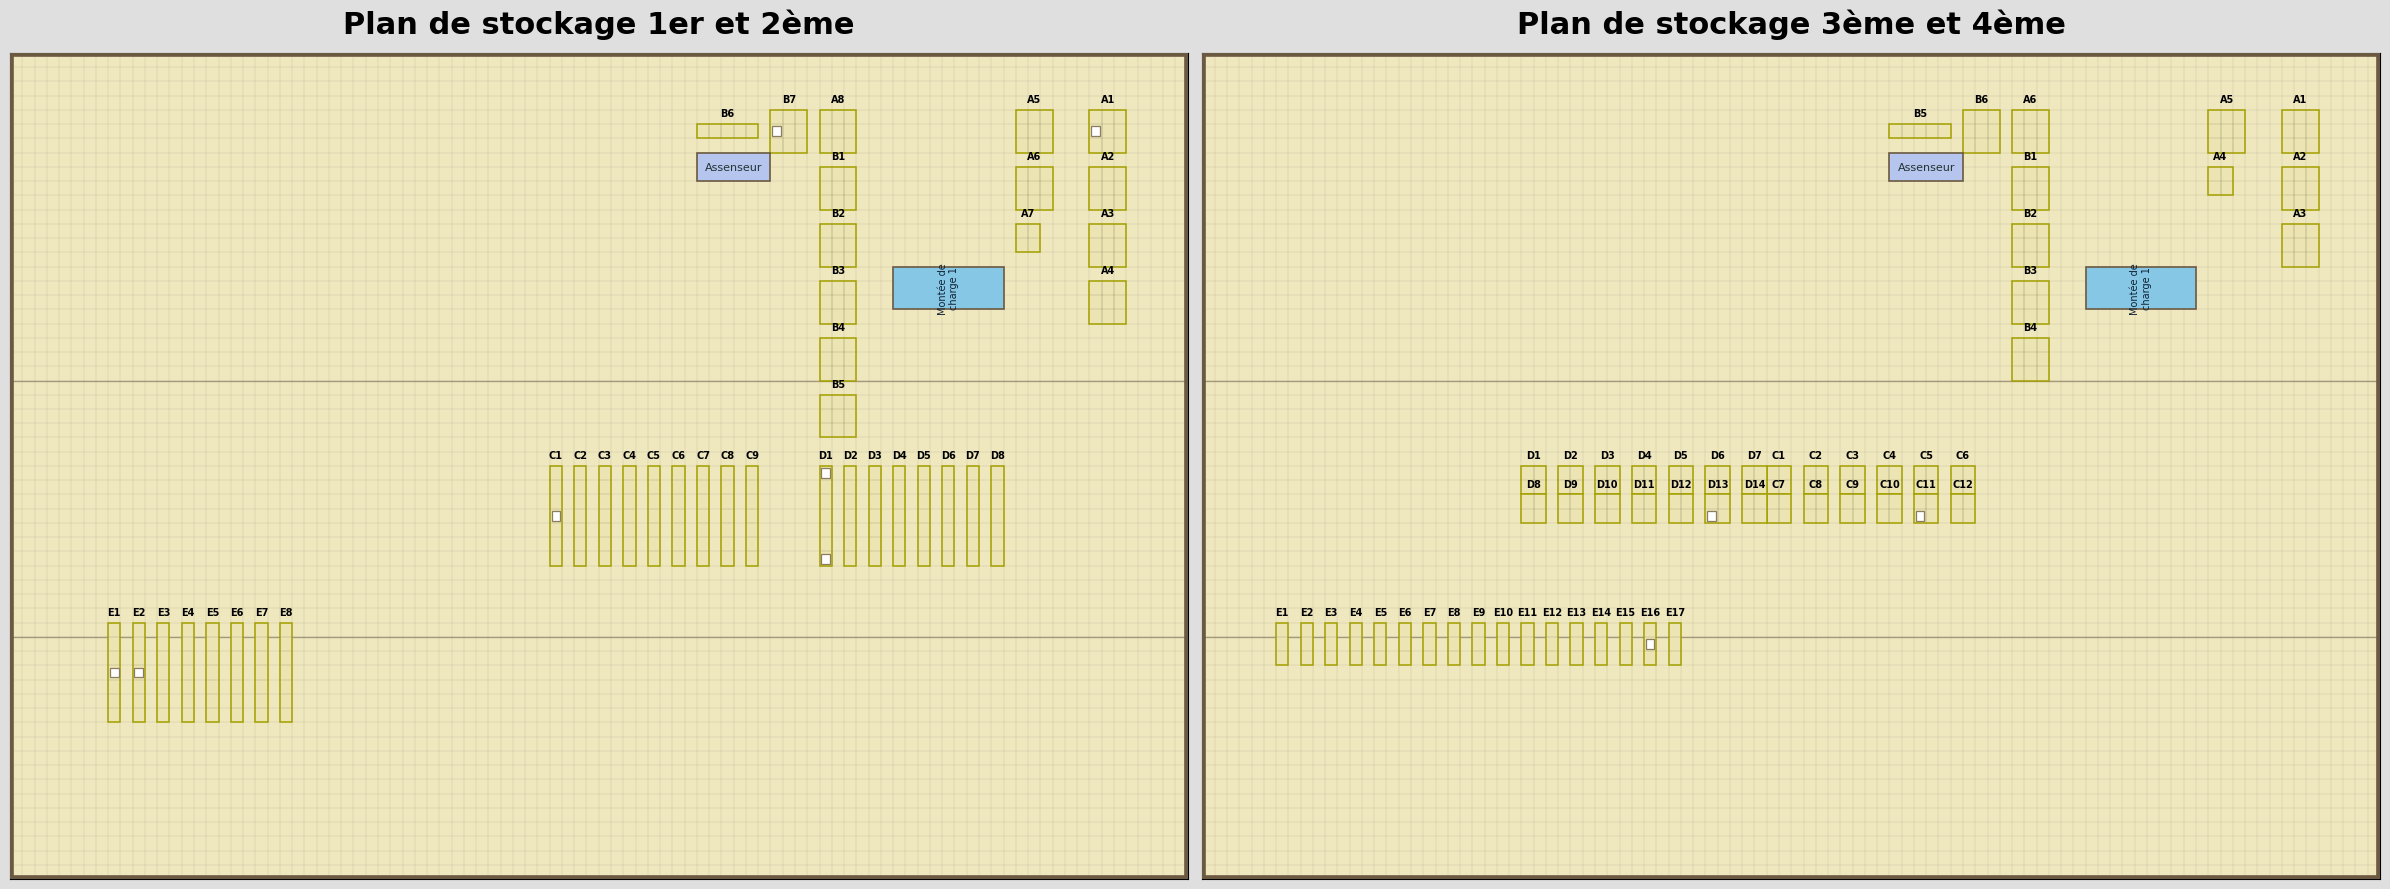

In [28]:
# Description: Execute the exact floor model, print full detailed report, and render both plans.

build_all_and_report(save_image=True)